# PepMSND Results Comparison

This notebook compares:
- `results_lg_models` (KAN setting)
- `results_pepmsnd_justBERTlg` (BERT-only setting)

It reproduces fold-wise best-threshold MCC scoring and creates a figure with mean +/- std and fold-level points.

In [19]:
from pathlib import Path

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import matthews_corrcoef


EXPERIMENTS = {
    "results_lg_models (KAN)": os.path.join("figure_data", "fig5B_BERT+KAN_predictions_all_models.csv"),
    "results_pepmsnd_justBERTlg (BERT-only)": os.path.join("figure_data", "fig5B_BERT-ONLY_predictions_all_models.csv"),
}

for name, path in EXPERIMENTS.items():
    print(f"{name}: {os.path.exists(path)} -> {path}")

results_lg_models (KAN): True -> figure_data/fig5B_BERT+KAN_predictions_all_models.csv
results_pepmsnd_justBERTlg (BERT-only): True -> figure_data/fig5B_BERT-ONLY_predictions_all_models.csv


In [20]:
def find_best_mcc_threshold(y_true, y_prob):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    y_true_bin = (y_true >= 0.5).astype(int)

    unique_thresholds = np.unique(y_prob)
    if unique_thresholds.size == 0:
        return 0.5, float("nan")

    candidates = np.concatenate([
        [np.nextafter(unique_thresholds[0], -np.inf)],
        unique_thresholds,
        [np.nextafter(unique_thresholds[-1], np.inf)],
    ])

    best_t = float(candidates[0])
    best_mcc = -np.inf

    for t in candidates:
        y_pred = (y_prob >= t).astype(int)
        mcc = matthews_corrcoef(y_true_bin, y_pred)
        if np.isnan(mcc):
            mcc = -1.0

        if (mcc > best_mcc + 1e-12) or (
            abs(mcc - best_mcc) <= 1e-12 and abs(t - 0.5) < abs(best_t - 0.5)
        ):
            best_mcc = float(mcc)
            best_t = float(t)

    return best_t, best_mcc


def score_experiment(csv_path: Path, experiment_name: str):
    df = pd.read_csv(csv_path).copy()

    required = {"molecule", "true", "predicted"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns for {experiment_name}: {missing}")

    fold = df["molecule"].astype(str).str.extract(r"fold(\d+)_")[0]
    df = df.loc[fold.notna()].copy()
    if df.empty:
        raise ValueError(
            f"No fold IDs parsed for {experiment_name}; expected molecule format like fold1_idx0."
        )
    df["fold"] = fold[fold.notna()].astype(int).to_numpy()

    if "model" not in df.columns:
        df["model"] = "__single__"

    model_summary_rows = []
    model_fold_rows = []

    for model, g_model in sorted(df.groupby("model")):
        fold_rows = []
        for fold_id, g_fold in sorted(g_model.groupby("fold")):
            best_t, mcc = find_best_mcc_threshold(
                g_fold["true"].to_numpy(), g_fold["predicted"].to_numpy()
            )
            fold_rows.append((int(fold_id), float(mcc), float(best_t), int(len(g_fold))))
            model_fold_rows.append(
                {
                    "experiment": experiment_name,
                    "model": model,
                    "fold": int(fold_id),
                    "mcc": float(mcc),
                    "threshold": float(best_t),
                    "n": int(len(g_fold)),
                }
            )

        if not fold_rows:
            continue

        mccs = [r[1] for r in fold_rows]
        model_summary_rows.append(
            {
                "experiment": experiment_name,
                "model": model,
                "mean_mcc": float(np.mean(mccs)),
                "std_mcc": float(np.std(mccs)),
                "n_folds": len(fold_rows),
            }
        )

    if not model_fold_rows:
        raise ValueError(f"No model/fold rows generated for {experiment_name}.")

    model_summary_df = pd.DataFrame(model_summary_rows)
    model_fold_df = pd.DataFrame(model_fold_rows).sort_values(["model", "fold"])
    return model_summary_df, model_fold_df

Saved figure to: figures/fig5B_pepmsnd_compare_grouped_by_model.png


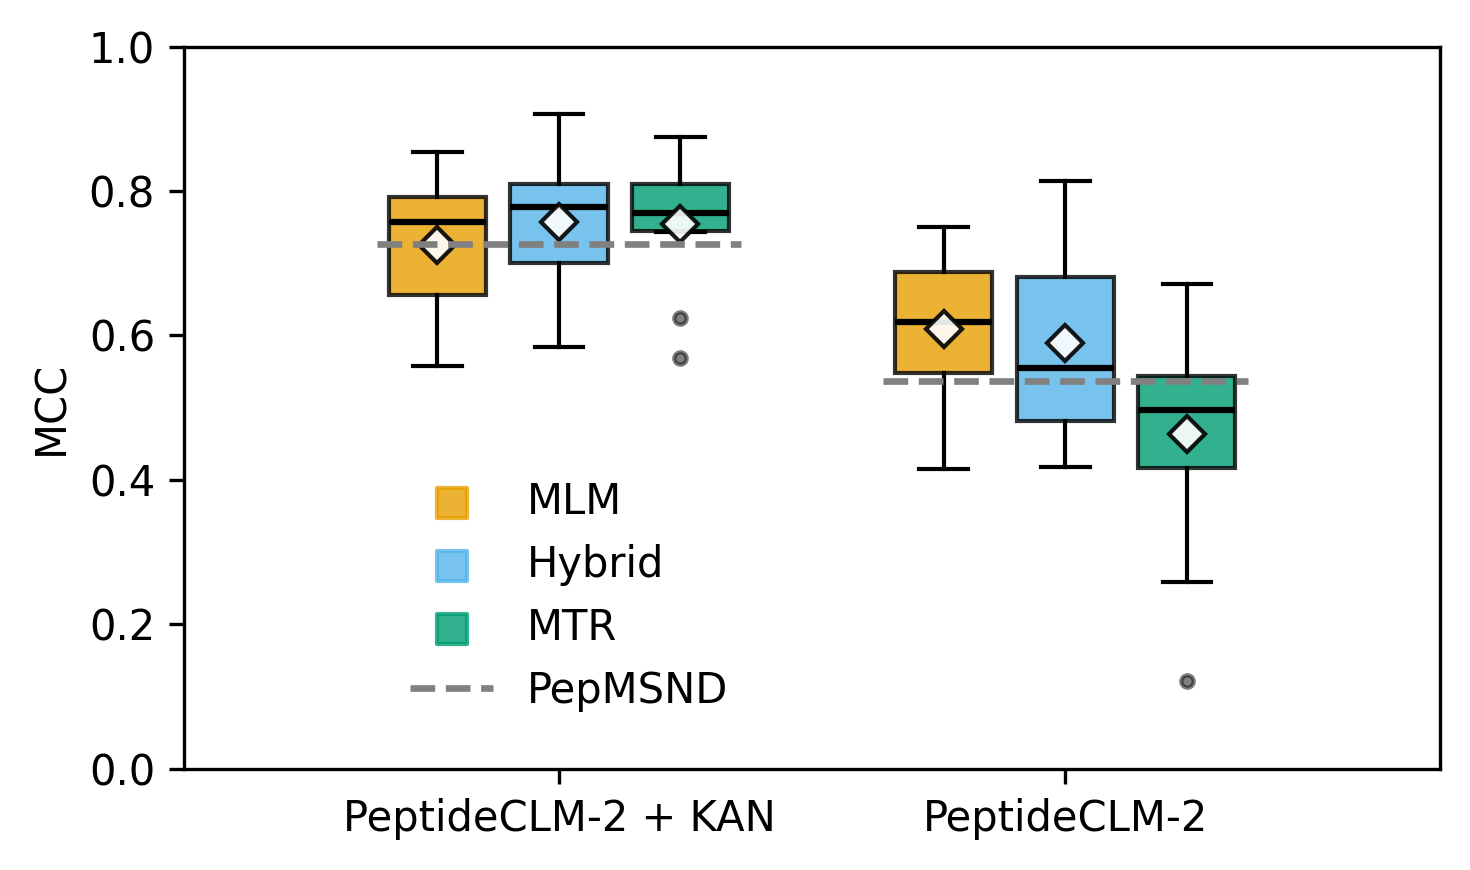

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Configuration and Constants
# PLOT_COLORS = ["#1b9e77", "#d95f02", "#7570b3", "#e7298a"]
PLOT_COLORS = ["#E69F00", "#56B4E9", "#009E73", "#e7298a"]

MODEL_LABELS = {
    "aaronfeller_PeptideMLM_lg": "MLM",
    "aaronfeller_PeptideMLM-MTR_lg": "Hybrid",
    "aaronfeller_PeptideMTR_lg": "MTR",
}

BASELINE_COLOR = "#808080"
BASELINE_LABEL = "PepMSND"

OUTPUT_PATH = os.path.join("figures", "fig5B_pepmsnd_compare_grouped_by_model.png")

# 2. Data Preparation
plot_df = all_model_folds.copy()
exp_order = list(EXPERIMENTS.keys())
model_order = [
    "aaronfeller_PeptideMLM_lg", 
    "aaronfeller_PeptideMLM-MTR_lg", 
    "aaronfeller_PeptideMTR_lg"
]

# 3. Plot Setup
fig, ax = plt.subplots(figsize=(5, 3), dpi=300)
x_positions = np.arange(len(exp_order), dtype=float)

# Adjust widths and offsets for the groups
total_bars = len(model_order)
bar_width = 0.24
max_offset = bar_width * (total_bars - 1) / 2
offsets = np.linspace(-max_offset, max_offset, num=total_bars)

# 4. Plotting Loop for Dynamic Models (Box Plots)
for i, model_name in enumerate(model_order):
    current_x = x_positions + offsets[i]
    color = PLOT_COLORS[i % len(PLOT_COLORS)]
    label = MODEL_LABELS.get(model_name, model_name)

    box_data = []
    valid_positions = []
    
    for j, exp_name in enumerate(exp_order):
        fold_values = plot_df.loc[
            (plot_df["experiment"] == exp_name) & (plot_df["model"] == model_name),
            "mcc",
        ].to_numpy()
        
        # Only plot boxes where data exists
        if len(fold_values) > 0:
            box_data.append(fold_values)
            valid_positions.append(current_x[j])
            
    if box_data:
        ax.boxplot(
            box_data,
            positions=valid_positions,
            widths=bar_width * 0.8,
            patch_artist=True,
            boxprops=dict(facecolor=color, color="black", alpha=0.8),
            capprops=dict(color="black"),
            whiskerprops=dict(color="black"),
            flierprops=dict(marker="o", markerfacecolor="black", markersize=3, alpha=0.5),
            medianprops=dict(color="black", linewidth=1.5),
            # add mean marker
            showmeans=True,
            meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="black", markersize=6, alpha=0.9)
        )
        
    # Proxy artist to register the styling in the legend correctly
    ax.scatter([], [], color=color, alpha=0.8, label=label, marker='s', s=50)

# 5. Plotting the Baseline Model as Dashed Lines
for j, exp_name in enumerate(exp_order):
    exp_str = str(exp_name)
    if "KAN" in exp_str:
        base_val = 0.726
    elif "BERT" in exp_str:
        base_val = 0.537
    else:
        base_val = 0.0

    xmin = x_positions[j] - max_offset - (bar_width / 2)
    xmax = x_positions[j] + max_offset + (bar_width / 2)
    
    # Only label the first line to prevent duplicate legend entries
    lbl = BASELINE_LABEL if j == 0 else None
    
    ax.hlines(
        y=base_val, 
        xmin=xmin, 
        xmax=xmax, 
        colors=BASELINE_COLOR, 
        linestyles="dashed", 
        linewidth=1.6,
        label=lbl,
        zorder=4
    )

# 6. Formatting and Styling
ax.set_xticks(x_positions)
ax.set_xticklabels(["PeptideCLM-2 + KAN", "PeptideCLM-2"], rotation=0, ha="center")
ax.set_ylabel("MCC"),
# ax.set_title("PepMSND Comparison: Per-Model MCC by Experiment")
ax.set_ylim(0.0, 1.0)
# ax.grid(axis="y", linestyle="--", alpha=0.3, linewidth=0.1)
ax.legend(title="", frameon=False, bbox_to_anchor=(0.15, 0.45), loc="upper left")
fig.tight_layout()

# 7. Save and Display
fig.savefig(OUTPUT_PATH, bbox_inches="tight")
print(f"Saved figure to: {OUTPUT_PATH}")

plt.show()


In [23]:
import sys
print('python_executable:', sys.executable)

import torch
print('torch_version:', getattr(torch, '__version__', 'NA'))
print('torch_file:', getattr(torch, '__file__', None))
print('has_LongTensor:', hasattr(torch, 'LongTensor'))

from transformers import AutoTokenizer, AutoModel
print('transformers import: OK')

python_executable: /stor/work/Wilke/afeller/PeptideMTR_final_pub/PeptideMTR/.venv/bin/python
torch_version: 2.9.1+cu128
torch_file: /stor/work/Wilke/afeller/PeptideMTR_final_pub/PeptideMTR/.venv/lib/python3.10/site-packages/torch/__init__.py
has_LongTensor: True


/stor/work/Wilke/afeller/PeptideMTR_final_pub/PeptideMTR/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


transformers import: OK


## Pre-Finetuning Embedding Map

> Elegant 2D view of sequence-space structure before task-specific finetuning.

This section:
- loads a de-duplicated PepMSND set from `main/data/PepMSND_data/X_test*.csv` (10 folds),
- tries pooled backbone embeddings from `aaronfeller/PeptideMLM_lg`,
- falls back to descriptor embeddings automatically if `torch/transformers` are unavailable,
- projects embeddings to 2D using UMAP (or t-SNE fallback),
- visualizes structure by class label and peptide length.

In [32]:
import glob
import numpy as np
import pandas as pd

# Configuration
EMBED_MODEL = "aaronfeller/PeptideMLM_lg"
BATCH_SIZE = 64
MAX_LENGTH = 2046

rng = np.random.default_rng(SEED)


df = pd.read_csv(os.path.join("..", "data", "PepMSND_clustered_data.csv"))

# deduplicate by SMILES, keeping the first occurrence
df = df.drop_duplicates(subset="SMILES", keep="first").reset_index(drop=True)

def get_backbone_embeddings(smiles):
    import torch
    from transformers import AutoTokenizer, AutoModel

    device = "cuda" if torch.cuda.is_available() else "cpu"
    if device == "cpu":
        print("Warning: CUDA not available, stopping execution to avoid very slow processing on CPU.")
        raise ValueError("CUDA not available")
    print(f"Using device: {device}")
    
    tokenizer = AutoTokenizer.from_pretrained(EMBED_MODEL, trust_remote_code=True)
    backbone = AutoModel.from_pretrained(EMBED_MODEL, trust_remote_code=True).to(device).eval()

    def mean_pool(last_hidden_state, attention_mask):
        mask = attention_mask.to(last_hidden_state.dtype).unsqueeze(-1)
        summed = (last_hidden_state * mask).sum(dim=1)
        denom = mask.sum(dim=1).clamp(min=1e-6)
        return summed / denom

    all_emb = []
    with torch.no_grad():
        for i in range(0, len(smiles), BATCH_SIZE):
            batch = smiles[i : i + BATCH_SIZE]
            enc = tokenizer(batch, truncation=True, padding=True, max_length=MAX_LENGTH,
                            add_special_tokens=True, return_tensors="pt")
            
            input_ids = enc["input_ids"].to(device)
            attention_mask = enc["attention_mask"].to(device)
            outputs = backbone(input_ids=input_ids, attention_mask=attention_mask)
            
            if isinstance(outputs, dict) and "mean_pool" in outputs:
                pooled = outputs["mean_pool"]
            else:
                last_hidden = getattr(outputs, "last_hidden_state", outputs[0] if isinstance(outputs, (tuple, list)) else None)
                pooled = mean_pool(last_hidden, attention_mask)

            pooled = torch.nan_to_num(pooled.detach().float(), nan=0.0, posinf=0.0, neginf=0.0)
            all_emb.append(pooled.cpu())

    emb = torch.cat(all_emb, dim=0).numpy().astype(np.float64)
    finite_ratio = float(np.isfinite(emb).mean())
    nonzero_ratio = float(np.mean(np.linalg.norm(np.nan_to_num(emb, nan=0.0), axis=1) > 1e-8))

    if finite_ratio < 0.99 or nonzero_ratio < 0.5:
        raise ValueError("Backbone embedding matrix is non-finite or mostly degenerate.")
        
    return np.nan_to_num(emb, nan=0.0, posinf=0.0, neginf=0.0)

def get_descriptor_embeddings(df):
    meta_cols = {"ID", "PMID", "SMILES", "Length", "Species", "Environment", "SE-3", "label"}
    desc_cols = [c for c in df.columns if c not in meta_cols and pd.to_numeric(df[c], errors="coerce").notna().mean() > 0.95]

    if not desc_cols:
        raise ValueError("Could not infer numeric descriptor columns.")

    desc = df[desc_cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=np.float64)
    desc = np.nan_to_num(desc, nan=0.0, posinf=0.0, neginf=0.0)

    caps = np.nanpercentile(np.abs(desc), 99.5, axis=0)
    caps = np.where((~np.isfinite(caps)) | (caps <= 0), 1.0, caps)
    desc = np.clip(desc, -caps, caps)

    mu = np.nanmean(desc, axis=0, keepdims=True)
    sigma = np.where((s := np.nanstd(desc, axis=0, keepdims=True)) < 1e-8, 1.0, s)
    
    emb = np.nan_to_num((desc - mu) / sigma, nan=0.0, posinf=0.0, neginf=0.0)
    return emb, len(desc_cols)

# Execute
smiles = df["SMILES"].astype(str).tolist()

try:
    emb = get_backbone_embeddings(smiles)
    embedding_source = "Backbone pooled embedding"
except Exception as e:
    print(f"[WARN] Backbone embedding unavailable: {type(e).__name__}: {e}")
    emb, n_features = get_descriptor_embeddings(df)
    embedding_source = f"Descriptor embedding ({n_features} features)"

# Final normalization
emb = np.nan_to_num(emb, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float64)
norms = np.where((n := np.linalg.norm(emb, axis=1, keepdims=True)) < 1e-12, 1.0, n)
emb = emb / norms

# save the embeddings
np.save("figure_data/plotting_embeddings.npy", emb)


[WARN] Backbone embedding unavailable: ValueError: CUDA not available


/stor/work/Wilke/afeller/PeptideMTR_final_pub/PeptideMTR/.venv/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1872: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


In [33]:
emb.shape

(605, 141)

In [39]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
SEED = 7

df = pd.read_csv(os.path.join("..", "data", "PepMSND_clustered_data.csv"))
# deduplicate by SMILES, keeping the first occurrence
df = df.drop_duplicates(subset="SMILES", keep="first").reset_index(drop=True)

# load embeddings
emb = np.load("figure_data/fig5A_embeddings.npy")

def reduce_dimensions(emb):
    perplexity = 15
    reducer = TSNE(n_components=2, perplexity=perplexity, learning_rate="auto", init="pca", random_state=SEED)
    return reducer.fit_transform(emb), "t-SNE"

emb_2d, proj_name = reduce_dimensions(emb)

plot_df = pd.DataFrame({
    "x": emb_2d[:, 0],
    "y": emb_2d[:, 1],
    "label": df["label"].astype(int).to_numpy(),
    "length": pd.to_numeric(df["Length"], errors="coerce").fillna(0).to_numpy(),
    "species": df["Species"].astype(str).to_numpy(),
    "environment": df["Environment"].astype(str).to_numpy(),
})

print(f"Loaded samples: {len(df)}")
print(f"Embedding matrix: {emb.shape} | source: {embedding_source}")

plot_df.to_csv("figure_data/fig5A_embedding_2d_projection.csv", index=False)
print(f"Saved 2D embedding projection and metadata to: figure_data/fig5A_embedding_2d_projection.csv")


Loaded samples: 605
Embedding matrix: (605, 141) | source: Descriptor embedding (141 features)
Saved 2D embedding projection and metadata to: figure_data/fig5A_embedding_2d_projection.csv


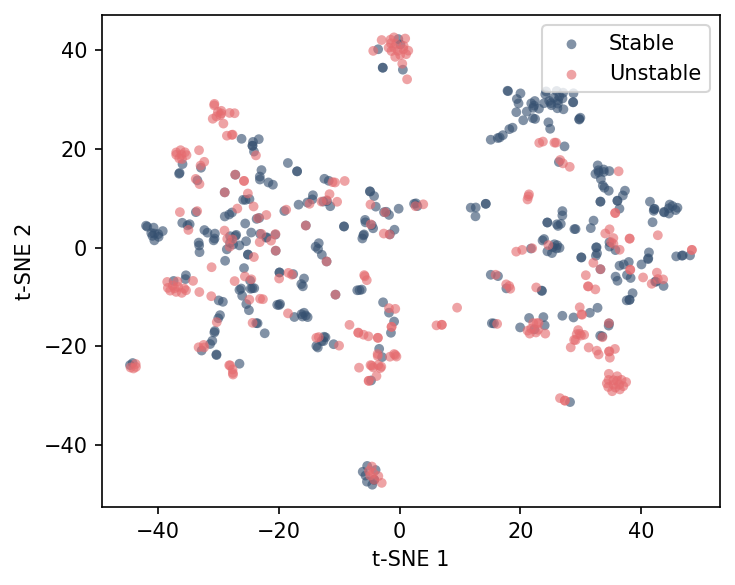

In [42]:
import matplotlib.pyplot as plt
import pandas as pd

# load the 2D projection and metadata if needed
plot_df = pd.read_csv("figure_data/fig5A_embedding_2d_projection.csv")

# make single plot 
fig, axes = plt.subplots(1, 1, figsize=(5, 4), dpi=150)

# Panel A: Class Label
palette = {0: "#355070", 1: "#E56B6F"}
for cls in sorted(plot_df["label"].unique()):
    g = plot_df[plot_df["label"] == cls]
    plt.scatter(
        g["x"], g["y"], s=22, alpha=0.62,
        c=palette.get(int(cls), "#666666"),
        edgecolors="none", label=f"label={int(cls)}"
    )

# plt.title(f"{proj_name} ({embedding_source}) by label")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
# plt.grid(alpha=0.2, linestyle="--")
# change label to "Stable (0) vs Unstable (1)"
plt.legend(["Stable", "Unstable"], frameon=True, loc="upper right")


# fig.suptitle("PepMSND Pre-Finetuning Embedding Landscape", y=1.02, fontsize=12)
fig.tight_layout()
plt.savefig("figures/fig5A_pepmsnd_embedding_by_label.png", dpi=300, bbox_inches="tight")
plt.show()